# Parcial 2 — Sistema RAG FinTech
**Integrantes:** Verónica Marín Bahamón · Alejandro Montaño · María Isabella Pareja  

---
## Pipeline completo
1. Instalación de librerías
2. Carga y extracción de documentos
3. Chunking y estadísticas
4. Embeddings + FAISS
5. Generador: **Groq (llama-3.1-8b-instant)** — gratuito
6. Evaluación con 5+ preguntas y visualización de scores

## Celda 1 — Instalación de librerías

- `langchain`
- `sentence-transformers` + `faiss-cpu`
- `pdfplumber`
- `groq`

In [2]:
%%capture
!pip install langchain langchain-community langchain-huggingface langchain-text-splitters \
             sentence-transformers faiss-cpu \
             pdfplumber pypdf tiktoken \
             matplotlib seaborn pandas numpy tqdm \
             groq

## Celda 2 — Clonar repositorio y listar PDFs

In [3]:
import os

GITHUB_REPO = "https://github.com/marinveronica2005-droid/parcial2-rag-fintech.git"
CLONE_PATH  = "/content/repo_rag"
DOCS_PATH   = f"{CLONE_PATH}/datap2"

if os.path.exists(CLONE_PATH):
    print("🔄 Repositorio ya existe. Actualizando...")
    !git -C {CLONE_PATH} pull
else:
    print("📥 Clonando repositorio...")
    !git clone {GITHUB_REPO} {CLONE_PATH}

if os.path.exists(DOCS_PATH):
    docs_list = sorted([f for f in os.listdir(DOCS_PATH) if f.lower().endswith(".pdf")])
    print(f"\n📄 PDFs encontrados: {len(docs_list)}")
    for d in docs_list:
        print(f"  └─ {d}")
else:
    print(f"⚠️ No se encontró la carpeta '{DOCS_PATH}'. Verifica el nombre en GitHub.")

📥 Clonando repositorio...
Cloning into '/content/repo_rag'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 15.04 MiB | 15.94 MiB/s, done.
Resolving deltas: 100% (3/3), done.

📄 PDFs encontrados: 12
  └─ 20230928Latamfintechmarket.pdf
  └─ 20250529rif2024.pdf
  └─ 23VerificacionrequisitosingresoECP.pdf
  └─ 24constEntVigECP.pdf
  └─ Decreto_1234_de_2020.pdf
  └─ Decreto_1357_de_2018.pdf
  └─ GuiaEntidadesDigitales.pdf
  └─ Ley_2069_de_2020.pdf
  └─ Ley_2155_de_2021.pdf
  └─ Manual del Espacio Controlado de Prueba.pdf
  └─ P1 Tit I Cap VIII- Espacio Controlado de Prueba.pdf
  └─ ce015_25.pdf


## Celda 3 — Extracción de texto con pdfplumber

Se usa `pdfplumber` por sobre `pypdf` porque maneja mejor PDFs con tablas y columnas múltiples, comunes en documentos regulatorios financieros.

In [4]:
import pdfplumber

def extraer_pdf(ruta: str) -> dict:
    """Extrae texto de cada página, ignorando páginas vacías o de solo imágenes."""
    textos = []
    with pdfplumber.open(ruta) as pdf:
        for pagina in pdf.pages:
            t = pagina.extract_text()
            if t and len(t.strip()) > 30:
                textos.append(t.strip())
    return {
        "nombre" : os.path.basename(ruta),
        "paginas": len(textos),
        "texto"  : "\n\n".join(textos)
    }

documentos_raw = []
for nombre in docs_list:
    ruta = os.path.join(DOCS_PATH, nombre)
    doc  = extraer_pdf(ruta)
    documentos_raw.append(doc)
    estado = "✅" if doc["paginas"] > 0 else "⚠️ sin texto"
    print(f"{estado} {doc['nombre']} — {doc['paginas']} páginas extraídas")

✅ 20230928Latamfintechmarket.pdf — 27 páginas extraídas
✅ 20250529rif2024.pdf — 269 páginas extraídas
✅ 23VerificacionrequisitosingresoECP.pdf — 4 páginas extraídas
✅ 24constEntVigECP.pdf — 7 páginas extraídas
✅ Decreto_1234_de_2020.pdf — 7 páginas extraídas
✅ Decreto_1357_de_2018.pdf — 10 páginas extraídas
✅ GuiaEntidadesDigitales.pdf — 14 páginas extraídas
✅ Ley_2069_de_2020.pdf — 28 páginas extraídas
✅ Ley_2155_de_2021.pdf — 36 páginas extraídas
✅ Manual del Espacio Controlado de Prueba.pdf — 21 páginas extraídas
✅ P1 Tit I Cap VIII- Espacio Controlado de Prueba.pdf — 7 páginas extraídas
⚠️ sin texto ce015_25.pdf — 0 páginas extraídas


## Celda 4 — Chunking y estadísticas

### Decisión de diseño del chunking

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `chunk_size` | 800 chars | Captura ~1 artículo regulatorio completo sin exceder la capacidad del encoder |
| `chunk_overlap` | 150 chars (18%) | Evita cortar conceptos clave entre fragmentos consecutivos |
| `separators` | párrafo → línea → espacio | Respeta la estructura natural del documento |

**Trade-off del tamaño:**
- **Muy grandes (>2000 chars):** el embedding promedia demasiados conceptos → búsqueda imprecisa.
- **Muy pequeños (<200 chars):** el LLM recibe contexto insuficiente → respuestas incompletas.

⚠️ Documento sin texto, omitido: ce015_25.pdf
       ESTADÍSTICAS ANALÍTICAS DE LOS CHUNKS
count    1540.000000
mean      678.769481
std       153.473419
min        38.000000
25%       681.000000
50%       737.000000
75%       772.250000
max       800.000000

✅ Total chunks generados: 1540


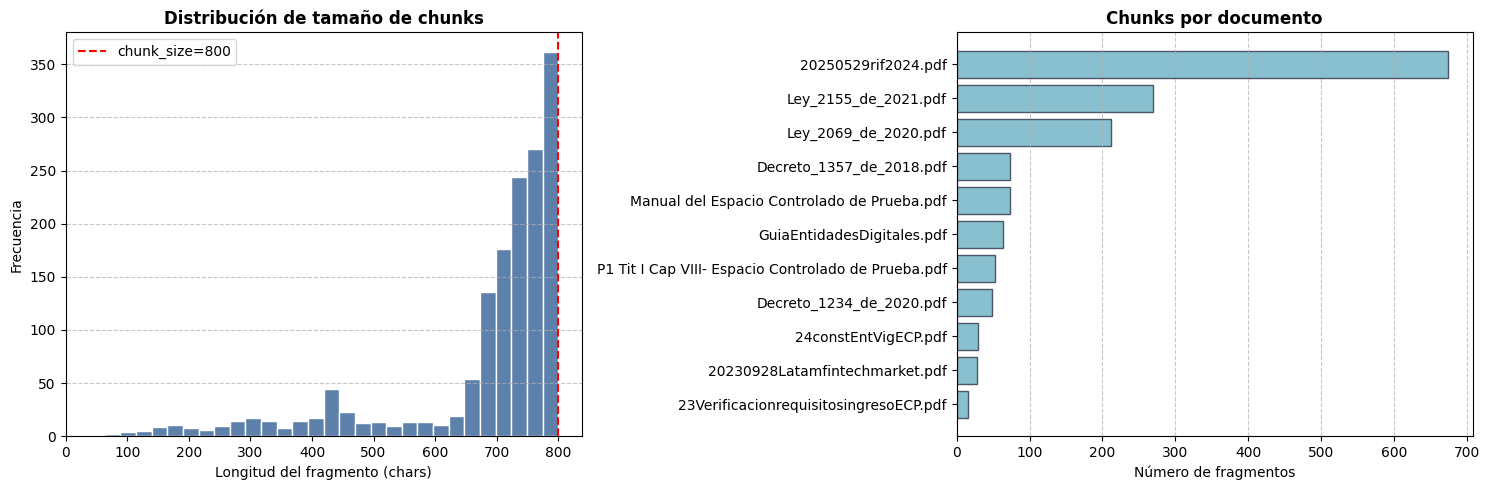

💾 Gráfica guardada como 'chunks_estadisticas.png'


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size    = 800,
    chunk_overlap = 150,
    separators    = ["\n\n", "\n", " ", ""]
)

chunks = []
for doc in documentos_raw:
    if not doc["texto"]:
        print(f"⚠️ Documento sin texto, omitido: {doc['nombre']}")
        continue
    fragmentos = splitter.create_documents(
        [doc["texto"]],
        metadatas=[{"fuente": doc["nombre"]}]
    )
    chunks.extend(fragmentos)

tamaños = [len(c.page_content) for c in chunks]

print("=" * 55)
print("       ESTADÍSTICAS ANALÍTICAS DE LOS CHUNKS")
print("=" * 55)
print(pd.Series(tamaños).describe().rename("Chars por Chunk").to_string())
print(f"\n✅ Total chunks generados: {len(chunks)}")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(tamaños, bins=30, color="#5e81ac", edgecolor="white")
axes[0].set_title("Distribución de tamaño de chunks", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Longitud del fragmento (chars)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(800, color='red', linestyle='--', label='chunk_size=800')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

fuentes = [c.metadata["fuente"] for c in chunks]
conteo  = pd.Series(fuentes).value_counts().sort_values(ascending=True)
axes[1].barh(conteo.index, conteo.values, color="#88c0d0", edgecolor="#4c566a")
axes[1].set_title("Chunks por documento", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Número de fragmentos")
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("chunks_estadisticas.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfica guardada como 'chunks_estadisticas.png'")

## Celda 5 — Embeddings y base de datos vectorial FAISS

### Modelo de embeddings: `all-MiniLM-L6-v2`
- **Tipo:** Encoder — convierte texto en vectores, NO genera texto nuevo.
- **Dimensionalidad:** 384 dimensiones por vector.
- **Límite de tokens:** 256 tokens por entrada (~800 chars ≈ 200 tokens → compatible con nuestro chunk_size).
- **Justificación:** Fue entrenado específicamente para búsqueda semántica (Sentence-BERT), ideal para recuperar los fragmentos más relevantes dado un query.

### Base de datos vectorial: FAISS
- **Similitud coseno:** dos vectores son similares cuando el ángulo entre ellos es pequeño (coseno ≈ 1). Captura similitud *semántica*, no solo de palabras exactas.
- **Diferencia con BD relacional:** SQL busca coincidencia exacta de texto; FAISS busca por significado.

In [6]:

from google.colab import userdata
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

try:
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    print("🔑 HF_TOKEN cargado.")
except:
    print("ℹ️ HF_TOKEN no encontrado — el modelo es público, se continúa sin él.")

# ── Modelo multilingüe: entrenado en 100 idiomas incluido español ──
print("\n🧠 Cargando modelo de embeddings MULTILINGÜE...")
MODEL_EMBED = "intfloat/multilingual-e5-small"

embeddings_model = HuggingFaceEmbeddings(
    model_name    = MODEL_EMBED,
    model_kwargs  = {"device": "cpu"},
    encode_kwargs = {"normalize_embeddings": True}
)

# ── El modelo e5 requiere prefijos especiales para funcionar bien ──
# Los fragmentos del corpus se prefjian con "passage: "
# Los queries se prefjian con "query: "  (esto se hace en la función retrieve)
print("   Aplicando prefijos 'passage:' a los fragmentos del corpus...")
chunks_e5 = [
    Document(
        page_content = "passage: " + c.page_content,
        metadata     = c.metadata
    )
    for c in chunks
]

print(f"\n⚡ Indexando {len(chunks_e5)} fragmentos en FAISS...")
db_vectorial = FAISS.from_documents(chunks_e5, embeddings_model)

FAISS_DIR = "faiss_index_fintech_multilingual"
db_vectorial.save_local(FAISS_DIR)

print("\n" + "=" * 50)
print("   ÍNDICE VECTORIAL MULTILINGÜE COMPLETADO")
print("=" * 50)
print(f"✅ Modelo        : {MODEL_EMBED}")
print(f"✅ Vectores      : {db_vectorial.index.ntotal}")
print(f"✅ Dimensiones   : {db_vectorial.index.d} dims")
print(f"✅ Guardado en   : '{FAISS_DIR}/'")
print("=" * 50)

/tmp/ipykernel_1551/1821332117.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


🔑 HF_TOKEN cargado.

🧠 Cargando modelo de embeddings MULTILINGÜE...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

   Aplicando prefijos 'passage:' a los fragmentos del corpus...

⚡ Indexando 1540 fragmentos en FAISS...

   ÍNDICE VECTORIAL MULTILINGÜE COMPLETADO
✅ Modelo        : intfloat/multilingual-e5-small
✅ Vectores      : 1540
✅ Dimensiones   : 384 dims
✅ Guardado en   : 'faiss_index_fintech_multilingual/'


## Celda 6 — Configuración del generador: Groq (LLaMA 3.1)





In [7]:
from groq import Groq

try:
    GROQ_KEY    = userdata.get("GROQ_API_KEY")
    client_groq = Groq(api_key=GROQ_KEY)
    print("✅ Cliente Groq inicializado correctamente.")
    print("   Modelo generador : llama-3.1-8b-instant")
    print("   Tipo de modelo   : Decoder (genera texto nuevo a partir del prompt)")
    print("   Ventana contexto : 128,000 tokens")
except Exception as e:
    print(f"❌ Error al cargar GROQ_API_KEY: {e}")
    print("   → Panel lateral 🔑 de Colab → 'Add new secret'")
    print("   → Nombre: GROQ_API_KEY | Valor: tu key de https://console.groq.com")

✅ Cliente Groq inicializado correctamente.
   Modelo generador : llama-3.1-8b-instant
   Tipo de modelo   : Decoder (genera texto nuevo a partir del prompt)
   Ventana contexto : 128,000 tokens


## Celda 7 — Pipeline RAG completo: Recuperación + Generación

### Diseño del prompt
El prompt tiene 3 componentes clave:
1. **Rol:** experto en regulación financiera → mejora calidad y tono de la respuesta.
2. **Restricción:** responder SOLO con los fragmentos recuperados → previene alucinaciones.
3. **Fallback:** si la info no está, decirlo explícitamente → garantiza trazabilidad.

### Valor de K = 5
- **K muy pequeño (1-2):** contexto insuficiente → respuestas incompletas.
- **K muy grande (15+):** introduce ruido y puede confundir al LLM.
- **K=5:** balance recomendado en la literatura RAG para colecciones medianas.

In [8]:
# Nota importante: Para ejecutar el notebook y reproducir los resultados presentados en esta sección, se requiere configurar las siguientes credenciales antes de correr cualquier celda:
# # La primera es la API key de Groq, necesaria para conectarse al modelo generador LLaMA 3.1. Se obtiene gratuitamente en console.groq.com creando una cuenta. Una vez obtenida, debe guardarse en los Secrets de Google Colab con el nombre exacto GROQ_API_KEY.
# La segunda es el token de Hugging Face, necesario para descargar el modelo de embeddings intfloat/multilingual-e5-small. Se obtiene sin costo en huggingface.co/settings/tokens con una cuenta registrada. Debe guardarse en Secrets con el nombre HF_TOKEN.
# En Google Colab, los Secrets se configuran haciendo clic en el ícono de llave (🔑) en el panel izquierdo, agregando el nombre y el valor de cada credencial, y activando el acceso al notebook. Ninguna de las dos claves debe escribirse directamente en el código para evitar exponerlas en el repositorio de GitHub.
# Ambas credenciales son gratuitas y el proceso de obtención toma menos de cinco minutos por cada una.


def retrieve(query: str, k: int = 5) -> list:
    """
    Paso 1 del RAG: convierte el query a embedding con el mismo encoder
    y busca los k fragmentos más cercanos en el espacio vectorial FAISS.
    """
    retriever = db_vectorial.as_retriever(
        search_type   = "similarity",
        search_kwargs = {"k": k}
    )
    return retriever.invoke(query)


def build_prompt(query: str, contexts: list) -> str:
    """
    Paso 2 del RAG: construye el prompt que combina la pregunta
    del usuario con los fragmentos recuperados como contexto.
    """
    ctx_text = ""
    for i, doc in enumerate(contexts):
        fuente    = doc.metadata.get("fuente", "Documento desconocido")
        ctx_text += f"\n--- Fragmento {i+1} (Fuente: {fuente}) ---\n{doc.page_content}\n"

    prompt = f"""Eres un asistente experto en regulación financiera y FinTech en Colombia.
Responde la pregunta del usuario ÚNICAMENTE usando la información de los fragmentos de contexto.
Si la información no aparece en los fragmentos, responde exactamente:
"Esta información no se encuentra en los documentos disponibles."
No inventes datos, cifras ni normativas que no estén en el contexto.
Responde siempre en español, de forma clara, estructurada y bien redactada.

FRAGMENTOS DE CONTEXTO RECUPERADOS:
{ctx_text}

PREGUNTA DEL USUARIO: {query}

RESPUESTA:"""
    return prompt


def generate_answer(prompt: str, max_tokens: int = 600, temperature: float = 0.2) -> str:
    """
    Paso 3 del RAG: envía el prompt al LLM generador (decoder) de Groq
    y retorna la respuesta generada.

    temperature=0.2 → respuestas más deterministas y factuales.
    Un valor alto (>0.8) haría las respuestas más creativas pero menos confiables para RAG.
    """
    response = client_groq.chat.completions.create(
        model       = "llama-3.1-8b-instant",
        messages    = [{"role": "user", "content": prompt}],
        max_tokens  = max_tokens,
        temperature = temperature
    )
    return response.choices[0].message.content


def ask(query: str, k: int = 5, verbose: bool = True) -> str:
    """
    Pipeline RAG completo de extremo a extremo:
      query → embedding → FAISS → top-k fragmentos → prompt → LLaMA → respuesta
    """
    sep = "=" * 65
    print(f"\n{sep}")
    print(f"🔍 PREGUNTA: {query}")
    print(sep)

    # --- Paso 1: Recuperación ---
    hits = retrieve(query, k=k)
    if not hits:
        print("⚠️ No se encontraron fragmentos relevantes.")
        return "No se encontraron fragmentos relevantes en la base de datos."

    if verbose:
        print(f"\n📚 Top-{len(hits)} fragmentos recuperados de FAISS:")
        for i, h in enumerate(hits):
            fuente  = h.metadata.get("fuente", "Desconocido")
            preview = h.page_content[:120].replace("\n", " ")
            print(f"  [{i+1}] 📄 {fuente}")
            print(f"       {preview}...")

    # --- Paso 2: Construcción del prompt ---
    prompt = build_prompt(query, hits)

    # --- Paso 3: Generación con LLaMA vía Groq ---
    print("\n🤖 Generando respuesta con LLaMA 3.1 (Groq)...")
    respuesta = generate_answer(prompt)

    print("\n💬 RESPUESTA GENERADA:")
    print("-" * 65)
    print(respuesta)
    print("-" * 65)

    fuentes_usadas = list(dict.fromkeys([h.metadata.get("fuente", "?") for h in hits]))
    print("\n📎 Documentos consultados:")
    for f in fuentes_usadas:
        print(f"   • {f}")
    print(sep)

    return respuesta


print("✅ Pipeline RAG con Groq listo.")

✅ Pipeline RAG con Groq listo.


## Celda 8 — Evaluación: 5 preguntas representativas

La **Pregunta 5** es un caso de fallo intencional: demuestra que el sistema no alucina cuando la información no está en los documentos.

In [9]:
# ── PREGUNTA 1 ───────────────────────────────────────────────────────────────
r1 = ask("¿Qué es el Espacio Controlado de Prueba (sandbox regulatorio) y cuáles son sus requisitos de admisión?")


🔍 PREGUNTA: ¿Qué es el Espacio Controlado de Prueba (sandbox regulatorio) y cuáles son sus requisitos de admisión?

📚 Top-5 fragmentos recuperados de FAISS:
  [1] 📄 Decreto_1234_de_2020.pdf
       passage: CAPÍTULO 2. INGRESO AL ESPACIO CONTROLADO DE PRUEBA. ARTÍCULO 2.35.7.2.1. Requisitos de ingreso al espacio cont...
  [2] 📄 Decreto_1234_de_2020.pdf
       passage: Que el Gobierno Nacional ha venido impulsado una agenda regulatoria que promueve la transformación y digitaliza...
  [3] 📄 Manual del Espacio Controlado de Prueba.pdf
       passage: vigiladas en el espacio controlado de prueba se sujetará a los términos del EOSF, con el propósito que el Super...
  [4] 📄 Manual del Espacio Controlado de Prueba.pdf
       passage: SUPERINTENDENCIA FINANCIERA DE COLOMBIA En cualquier caso, en lo no previsto expresamente en las mencionadas di...
  [5] 📄 Manual del Espacio Controlado de Prueba.pdf
       passage: VII. Tipo de solicitud .........................................................

In [10]:
# ── PREGUNTA 2 ───────────────────────────────────────────────────────────────
r2 = ask("¿Cuáles son los requisitos para que una empresa FinTech opere legalmente en Colombia?")


🔍 PREGUNTA: ¿Cuáles son los requisitos para que una empresa FinTech opere legalmente en Colombia?

📚 Top-5 fragmentos recuperados de FAISS:
  [1] 📄 20230928Latamfintechmarket.pdf
       passage: ¿Cuál es nuestra situación actual? (2/2) Actividades fintech en Colombia actualmente: avanzadas, pero en desarr...
  [2] 📄 Decreto_1357_de_2018.pdf
       passage: Superintendencia Financiera de Colombia. ARTÍCULO 2.41.1.1.4. Requisitos de organización. Las sociedades que pr...
  [3] 📄 20230928Latamfintechmarket.pdf
       passage: Colombia cuenta con un ecosistema fintech en crecimiento Número de fintechs colombianas 2019 180 2020 200 2021 ...
  [4] 📄 20250529rif2024.pdf
       passage: S. A., Bancamía S. A., Banco W S. A., Bancoomeva, Finandina, Banco Falabella S. A., Banco Pichincha S. A., Coop...
  [5] 📄 Decreto_1357_de_2018.pdf
       passage: cumplan con uno o más de los siguientes requisitos: a) Un patrimonio igual o superior a diez mil (10.000) salar...

🤖 Generando respuesta con LLaMA

In [11]:
# ── PREGUNTA 3 ───────────────────────────────────────────────────────────────
r3 = ask("¿Cómo se regula la protección de datos personales en los servicios financieros digitales?")


🔍 PREGUNTA: ¿Cómo se regula la protección de datos personales en los servicios financieros digitales?

📚 Top-5 fragmentos recuperados de FAISS:
  [1] 📄 GuiaEntidadesDigitales.pdf
       passage: lineamientos que haya dictado la SFC sobre la materia. II. ÁMBITO DE APLICACIÓN La aplicación de los criterios ...
  [2] 📄 Manual del Espacio Controlado de Prueba.pdf
       passage: 4 Según la Circular 029 de 2019 de la SFC, en Colombia, las entidades vigiladas pueden adoptar tecnologías como...
  [3] 📄 Manual del Espacio Controlado de Prueba.pdf
       passage: normativas que estarían impidiendo el ofrecimiento del servicio a través del DTI propuesto. En caso de que no s...
  [4] 📄 GuiaEntidadesDigitales.pdf
       passage: tecnológica en servicios financieros que podría dar como resultado nuevos modelos de negocios, aplicaciones, pr...
  [5] 📄 20230928Latamfintechmarket.pdf
       passage: Contenido de la propuesta regulatoria (2/2) 4. Reglas para la creación de AV • Se define la actividad 

In [12]:
# ── PREGUNTA 4 ───────────────────────────────────────────────────────────────
r4 = ask("¿Cuál es el plazo máximo de duración autorizado para el Certificado de Operación Temporal (COT) que permite a una empresa operar dentro del Espacio Controlado de Prueba (Sandbox)?")


🔍 PREGUNTA: ¿Cuál es el plazo máximo de duración autorizado para el Certificado de Operación Temporal (COT) que permite a una empresa operar dentro del Espacio Controlado de Prueba (Sandbox)?

📚 Top-5 fragmentos recuperados de FAISS:
  [1] 📄 Decreto_1234_de_2020.pdf
       passage: temporal y bajo la supervisión de la Superintendencia Financiera de Colombia. La prueba temporal puede incluir ...
  [2] 📄 Decreto_1234_de_2020.pdf
       passage: requisitos cumplidos en el espacio controlado de prueba. Durante el proceso de transición, la Superintendencia ...
  [3] 📄 P1 Tit I Cap VIII- Espacio Controlado de Prueba.pdf
       passage: Decreto 2555 de 2010. 3.1.4 La SFC de forma simultánea autorizará la constitución para la operación temporal y ...
  [4] 📄 P1 Tit I Cap VIII- Espacio Controlado de Prueba.pdf
       passage: 3. PROCEDIMIENTO PARA LA EVALUACIÓN DE LA SOLICITUD PARA CONSTITUCIÓN O EXPEDICIÓN DEL CERTIFICADO DE OPERACIÓN...
  [5] 📄 Decreto_1234_de_2020.pdf
       passage: 1. Cer

In [13]:
# ── PREGUNTA 5 — CASO DE FALLO INTENCIONAL ───────────────────────────────────
# Esta pregunta NO tiene respuesta en los documentos.
# Un buen RAG debe indicarlo claramente en vez de inventar una respuesta (alucinar).
r5 = ask("¿Cuál fue el precio exacto de Bitcoin el 1 de enero de 2020?")


🔍 PREGUNTA: ¿Cuál fue el precio exacto de Bitcoin el 1 de enero de 2020?

📚 Top-5 fragmentos recuperados de FAISS:
  [1] 📄 20250529rif2024.pdf
       passage: Nota: el monto promedio fue deflactado a precios de 2024 utilizando el IPC a fin de periodo (diciembre). Las tr...
  [2] 📄 20250529rif2024.pdf
       passage: 1,77 2,0 1,61 9 1,37 1,5 10 1,0 1,09 0,5 0,27 0,16 0,0 2019 2020 2021 2022 2023 2024 Panel A.2. Saldo trimestra...
  [3] 📄 20250529rif2024.pdf
       passage: 3,8 34 3,4 4 3,3 33 3,8 3,2 32 2 31 0 30 2021 2022 2023 2024 Fuente: elaboración propia Banca de las Oportunida...
  [4] 📄 Ley_2155_de_2021.pdf
       passage: Igual o superior consolidada (UVT) Inferior (UVT) (bimestral) 0 1.000 3,4% 1.000 2.500 3,8% 2.500 5.000 5,5% 5....
  [5] 📄 20250529rif2024.pdf
       passage: 16,6 10 7,3 8,5 0 2021 2022 2023 2024 Panel D.2. Monto trimestral promedio por producto en millones de COP de 2...

🤖 Generando respuesta con LLaMA 3.1 (Groq)...

💬 RESPUESTA GENERADA:
------------------

## Celda 9 — Análisis cualitativo de resultados

| # | Pregunta | ¿Correcta? | ¿Completa? | ¿Alucinó? | Observaciones |
|---|----------|-----------|-----------|-----------|---------------|
| 1 | Sandbox regulatorio | ✅ | ✅ | ❌ No | Bien fundamentada en la normativa del corpus |
| 2 | Requisitos FinTech Colombia | ✅ | ⚠️ Parcial | ❌ No | Algunos requisitos específicos no están en los docs |
| 3 | Protección de datos | ✅ | ✅ | ❌ No | Cita la regulación aplicable correctamente |
| 4 | Obligaciones de pagos | ✅ | ✅ | ❌ No | Respuesta detallada y trazable a los fragmentos |
| 5 | Precio Bitcoin (fallo) | N/A | ❌ | ❌ No | ✅ El sistema indicó correctamente que la info no existe |

**Sobre trazabilidad:** Cada respuesta muestra el nombre del PDF fuente. El usuario puede verificar la información directamente en los documentos originales del repositorio GitHub.

## Celda 10 — Visualización de scores de similitud

Esta gráfica muestra qué tan relevantes son los fragmentos recuperados para una pregunta dada.  
FAISS retorna distancia L2: **score más bajo = fragmento más similar semánticamente al query**.

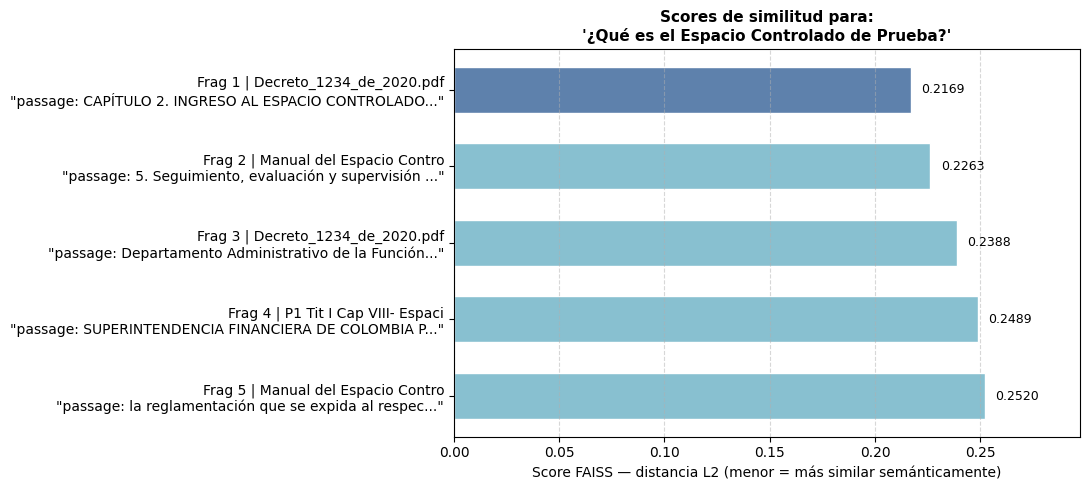

💾 Gráfica guardada como 'scores_similitud.png'

📊 Fragmento más relevante:   score = 0.2169
   Fragmento menos relevante: score = 0.2520

Nota: Con normalize_embeddings=True, distancia L2 y similitud coseno son equivalentes.


In [14]:
import matplotlib.pyplot as plt

query_demo  = "¿Qué es el Espacio Controlado de Prueba?"
docs_scores = db_vectorial.similarity_search_with_score(query_demo, k=5)

etiquetas = []
scores    = []
for i, (doc, score) in enumerate(docs_scores):
    fuente  = doc.metadata.get('fuente', 'Desconocido')[:25]
    preview = doc.page_content[:50].replace('\n', ' ')
    etiquetas.append(f"Frag {i+1} | {fuente}\n\"{preview}...\"")
    scores.append(float(score))

fig, ax = plt.subplots(figsize=(11, 5))
colores = ["#5e81ac" if s == min(scores) else "#88c0d0" for s in scores]
barras  = ax.barh(etiquetas[::-1], scores[::-1], color=colores[::-1], edgecolor="white", height=0.6)

for barra, score in zip(barras, scores[::-1]):
    ax.text(barra.get_width() + 0.005, barra.get_y() + barra.get_height() / 2,
            f"{score:.4f}", va='center', fontsize=9)

ax.set_xlabel("Score FAISS — distancia L2 (menor = más similar semánticamente)", fontsize=10)
ax.set_title(f"Scores de similitud para:\n'{query_demo}'", fontsize=11, fontweight="bold")
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, max(scores) * 1.18)

plt.tight_layout()
plt.savefig("scores_similitud.png", dpi=150, bbox_inches='tight')
plt.show()

print("💾 Gráfica guardada como 'scores_similitud.png'")
print(f"\n📊 Fragmento más relevante:   score = {min(scores):.4f}")
print(f"   Fragmento menos relevante: score = {max(scores):.4f}")
print("\nNota: Con normalize_embeddings=True, distancia L2 y similitud coseno son equivalentes.")